# 一般化加法モデル（GAM）で翌々年度保険料率を予測

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     11.6623
Link Function:                     IdentityLink Log Likelihood:                                    -0.1881
Number of Samples:                          141 AIC:                                               25.7007
                                                AICc:                                              28.4178
                                                GCV:                                                0.0748
                                                Scale:                                              0.2525
                                                Pseudo R-Squared:                                   0.2168
Feature Function                  Lam

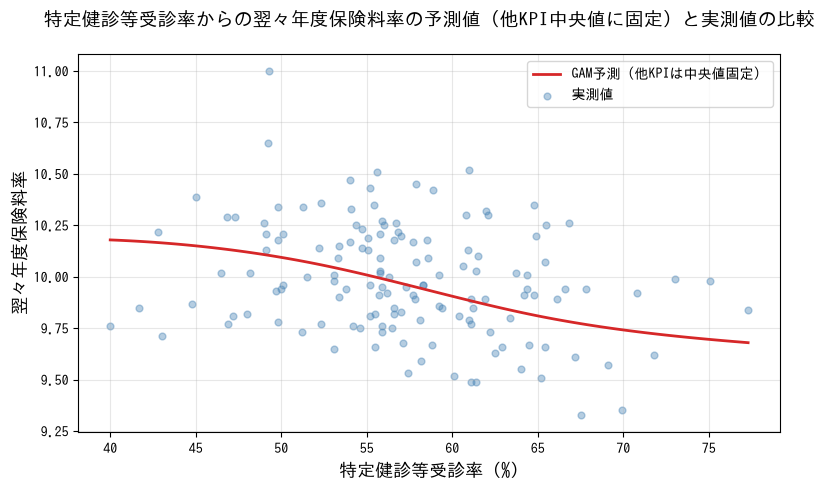


特定健診等以外を中央値に固定した予測値:
   特定健診等受診率(%)  予測 翌々年度保険料率
0         49.1        10.11
1         56.6         9.98
2         65.4         9.80


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csc_matrix, csr_matrix
from pygam import LinearGAM, s
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（IPAGothic）
plt.rcParams['font.family'] = 'IPAGothic'
plt.rcParams['axes.unicode_minus'] = False

# データ読み込み（v2: 病床数・地域差指数・県民所得を追加）
df = pd.read_csv('../data/分析用データ.tsv', sep='\t')
df = df.dropna()

# データ表示
# print(f"カラム ({len(df.columns)}個): {list(df.columns)}")
# print(f"データ件数: {len(df)} 行")
# print(f"年度: {sorted(df['年度'].unique())}")
# df.head()


## 重回帰モデル（全パラメーター）
feature_cols = [
    '特定健診等',       # 予防・健診系 KPI
    '特定保健指導',
    '受診勧奨',
    '後発医薬品',
    '対象者減少率',
    '調整前所要保険料率',
    '年齢調整',
    '所得調整',
    '精算分',
    'インセンティブ分',
]

X_multi = sm.add_constant(df[feature_cols])
y = df['翌々年度保険料率']

# pygam 0.9.x は SciPy の疎行列 .A 属性を参照するため、
# 新しい SciPy でも動くように互換プロパティを補います。
for sparse_cls in (csr_matrix, csc_matrix):
    if not hasattr(sparse_cls, 'A'):
        sparse_cls.A = property(lambda self: self.toarray())

gam_feature_cols = [
    '特定健診等',
    '特定保健指導',
    '受診勧奨',
    '後発医薬品',
    '対象者減少率',
]

gam_df = df[gam_feature_cols + ['翌々年度保険料率']].dropna()
X_gam = gam_df[gam_feature_cols].to_numpy()
y_gam = gam_df['翌々年度保険料率'].to_numpy()

def build_gam_terms(n_features, n_splines=6):
    gam_terms = s(0, n_splines=n_splines)
    for i in range(1, n_features):
        gam_terms += s(i, n_splines=n_splines)
    return gam_terms

terms = build_gam_terms(len(gam_feature_cols))

gam = LinearGAM(terms).fit(
    X_gam,
    y_gam,
)
gam.summary()

r2 = r2_score(y_gam, gam.predict(X_gam))
print('【GAM結果】')
print(f"  R-squared: {r2:.4f}")
print(f"  AIC: {gam.statistics_['AIC']:.2f}")
print(f"  有効自由度: {gam.statistics_['edof']:.2f}")
print(f"  選択された lambda: {np.asarray(gam.lam).ravel()[0]:.4g}")

# term=0（特定健診等）のグリッドを作成
XX = gam.generate_X_grid(term=0, n=100)

# 他のKPIを中央値に固定した「フル特徴量」グリッドを作成し、
# partial_dependence ではなく predict で絶対値スケールの予測曲線を得る
median_row = gam_df[gam_feature_cols].median().to_frame().T
XX_full = pd.concat([median_row] * len(XX), ignore_index=True)
XX_full['特定健診等'] = XX[:, 0]  # term=0 のグリッド値だけを差し替え

curve_pred = gam.predict(XX_full.to_numpy())
curve_ci = gam.confidence_intervals(XX_full.to_numpy(), width=0.95)


fig, ax = plt.subplots(figsize=(8, 5))

# 予測カーブ（絶対値スケール、他のKPIは中央値固定）
ax.plot(XX[:, 0], curve_pred, color='#d62728', linewidth=2, label='GAM予測（他KPIは中央値固定）')
# ax.fill_between(XX[:, 0], curve_ci[:, 0], curve_ci[:, 1], color='#d62728', alpha=0.18, label='95%信頼区間')

# 実測値（生のデータ点。他のKPIの値はバラバラなので、カーブからは外れて散らばる）
ax.scatter(
    gam_df['特定健診等'],
    gam_df['翌々年度保険料率'],
    color='steelblue',
    alpha=0.4,
    s=24,
    label='実測値',
)

ax.set_xlabel('特定健診等受診率 (%)', fontsize=13)
ax.set_ylabel('翌々年度保険料率', fontsize=13)
ax.set_title('特定健診等受診率からの翌々年度保険料率の予測値（他KPI中央値に固定）と実測値の比較\n', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 特定健診等の予測値を、観測範囲の下位・中央値・上位で比較します。
check_rates = np.percentile(gam_df['特定健診等'], [10, 50, 90])
check_X = pd.concat([median_row] * len(check_rates), ignore_index=True)
check_X['特定健診等'] = check_rates
check_pred = gam.predict(check_X.to_numpy())

print('\n特定健診等以外を中央値に固定した予測値:')
print(pd.DataFrame({
    '特定健診等受診率(%)': check_rates,
    '予測 翌々年度保険料率': check_pred,
}).round(2))

# モデルパラメーター

In [4]:
print("N", len(gam_df))
print("Explained deviance", gam.statistics_["pseudo_r2"]["explained_deviance"])
print("AIC", gam.statistics_["AIC"])
print("edof", gam.statistics_["edof"])
print("lambda", np.asarray(gam.lam).ravel().tolist())
print("link", gam.link)
print("distribution", gam.distribution)
print("coef_len", len(gam.coef_))
print("intercept", gam.coef_[-1])
print("feature_ranges")
print(gam_df[gam_feature_cols].agg(["min", "max", "median"]).T)

scaled_boundary_knots = np.array([0.0, 1 / 3, 2 / 3, 1.0])
scaled_augmented_knots = np.array([-1.0, -2 / 3, -1 / 3, 0.0, 1 / 3, 2 / 3, 1.0, 4 / 3, 5 / 3, 2.0])

print("\nKNOT_TABLE")
print("| feature | edge_knots_ | boundary knots | augmented knots used internally |")
print("|---|---|---|---|")
for col in gam_feature_cols:
    lower = float(gam_df[col].min())
    upper = float(gam_df[col].max())
    scale = upper - lower or 1.0
    boundary = lower + scale * scaled_boundary_knots
    augmented = lower + scale * scaled_augmented_knots
    fmt = lambda values: "[" + ", ".join(f"{value:.6g}" for value in values) + "]"
    print(f"| {col} | {fmt([lower, upper])} | {fmt(boundary)} | {fmt(augmented)} |")

offset = 0
for term_index, term in enumerate(gam.terms):
    n_coefs = term.n_coefs
    coefs = gam.coef_[offset : offset + n_coefs]
    offset += n_coefs
    print(f"\nTERM {term_index}")
    print("class", type(term).__name__)
    print("repr", term)
    print("n_coefs", n_coefs)
    print("coefs", np.array2string(coefs, precision=10, separator=", "))
    print("info", term.info)
    for attr in [
        "feature",
        "basis",
        "n_splines",
        "spline_order",
        "edge_knots_",
        "edge_knots",
        "_edge_knots",
        "lam",
        "penalties",
        "constraints",
        "dtype",
    ]:
        if hasattr(term, attr):
            print(attr, getattr(term, attr))

N 141
Explained deviance 0.21676779829303816
AIC 25.7006862853925
edof 11.662253726285622
lambda [0.6, 0.6, 0.6, 0.6, 0.6]
link identity
distribution normal
coef_len 31
intercept 5.514299243984977
feature_ranges
         min   max  median
特定健診等   40.0  77.3    56.6
特定保健指導   6.6  36.2    18.7
受診勧奨     7.9  40.2    11.0
後発医薬品   72.1  89.3    80.8
対象者減少率  29.3  37.2    34.0

KNOT_TABLE
| feature | edge_knots_ | boundary knots | augmented knots used internally |
|---|---|---|---|
| 特定健診等 | [40, 77.3] | [40, 52.4333, 64.8667, 77.3] | [2.7, 15.1333, 27.5667, 40, 52.4333, 64.8667, 77.3, 89.7333, 102.167, 114.6] |
| 特定保健指導 | [6.6, 36.2] | [6.6, 16.4667, 26.3333, 36.2] | [-23, -13.1333, -3.26667, 6.6, 16.4667, 26.3333, 36.2, 46.0667, 55.9333, 65.8] |
| 受診勧奨 | [7.9, 40.2] | [7.9, 18.6667, 29.4333, 40.2] | [-24.4, -13.6333, -2.86667, 7.9, 18.6667, 29.4333, 40.2, 50.9667, 61.7333, 72.5] |
| 後発医薬品 | [72.1, 89.3] | [72.1, 77.8333, 83.5667, 89.3] | [54.9, 60.6333, 66.3667, 72.1, 77.8333, 83.5667, 89.